# Performance Test Classification — Prediction Demo

**Quick demonstration of the trained Random Forest model making predictions on 3 test cases.**

This notebook is completely **standalone** — no database connection required!

**What's included:**
- Load pre-trained model, scaler, and test cases from `models/` and `test_cases/`
- Run predictions on 3 representative test cases
- Display confidence scores and feature explanations
- Visualize feature importance

**Audience:** Professors, reviewers, or anyone wanting to see the model in action without setup.

---

### 📍 How to Run This Notebook

**Option 1: MyBinder** (No installation required!)
- Click: [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/sahilailawadi/classification_supervised_learning_assignment/HEAD?labpath=notebooks%2Fpredict_demo.ipynb)
- Your browser will launch a live Jupyter environment

**Option 2: Local Jupyter**
- Clone the repo: `git clone https://github.com/sahilailawadi/classification_supervised_learning_assignment.git`
- Navigate to project root: `cd classification_supervised_learning_assignment`
- Run: `jupyter notebook notebooks/predict_demo.ipynb`

---

In [ ]:
# ============================================================================
# SETUP - Import Libraries and Configure Environment
# ============================================================================

import os
import sys

# Ensure we're in the project root directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"📂 Working directory: {os.getcwd()}")

# Add project root to path
sys.path.insert(0, os.path.abspath('.'))

# Import libraries
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 30)

# Verify required files exist
required_files = [
    'models/model.pkl',
    'models/scaler.pkl',
    'models/metrics.json',
    'test_cases/test_cases.json'
]

print("\n🔍 Verifying required files:")
all_exist = True
for file in required_files:
    exists = os.path.exists(file)
    status = "✅" if exists else "❌"
    print(f"  {status} {file}")
    if not exists:
        all_exist = False

if all_exist:
    print("\n✅ All required files found - ready to proceed!")
else:
    print("\n❌ Some files are missing.")
    print("   Make sure you've cloned the full repository and are running from the project root.")

💻 Running locally
📂 Working directory: /Users/sailaw864@cable.comcast.com/Desktop/Drexel/INFO629/Assignments/A3_Code

🔍 Verifying required files:
  ✅ models/model.pkl
  ✅ models/scaler.pkl
  ✅ models/metrics.json
  ✅ test_cases/test_cases.json

✅ All required files found - ready to proceed!


## 1. Load Pre-Trained Model & Test Cases

All artifacts are included in the repository.

**Files loaded:**
- `models/model.pkl` - Trained Random Forest classifier
- `models/scaler.pkl` - Feature scaler
- `models/metrics.json` - Performance metrics for all models
- `test_cases/test_cases.json` - 3 representative test cases

In [10]:
# Load model, scaler, and metrics
model = joblib.load('models/model.pkl')
scaler = joblib.load('models/scaler.pkl')

with open('models/metrics.json', 'r') as f:
    metrics = json.load(f)

# Load test cases
with open('test_cases/test_cases.json', 'r') as f:
    test_cases = json.load(f)

print('\n📊 Model Performance Comparison (on 20% remaining test run data):\n')

# Create DataFrame for tabular view
model_data = []
for model_name, model_metrics in metrics.items():
    if model_name == 'best_model':
        continue
    model_data.append({
        'Model': model_name,
        'Accuracy': f"{model_metrics['accuracy']:.2%}",
        'Balanced Accuracy': f"{model_metrics['balanced_accuracy']:.2%}",
        'Precision': f"{model_metrics['precision']:.2%}",
        'Recall': f"{model_metrics['recall']:.2%}",
        'F1-Score': f"{model_metrics['f1_score']:.2%}",
        'ROC-AUC': f"{model_metrics['roc_auc']:.3f}"
    })

comparison_df = pd.DataFrame(model_data)
print(comparison_df.to_string(index=False))

best = metrics['best_model']
print(f'\n✅ Best Model: {best}')
print(f'   Accuracy:          {metrics[best]["accuracy"]:.2%}')
print(f'   Balanced Accuracy: {metrics[best]["balanced_accuracy"]:.2%}')
print(f'   Precision:         {metrics[best]["precision"]:.2%}')
print(f'   Recall:            {metrics[best]["recall"]:.2%}')
print(f'   F1-Score:          {metrics[best]["f1_score"]:.2%}')
print(f'   ROC-AUC:           {metrics[best]["roc_auc"]:.3f}')



📊 Model Performance Comparison (on 20% remaining test run data):

        Model Accuracy Balanced Accuracy Precision Recall F1-Score ROC-AUC
Decision Tree   87.41%            87.08%    89.16% 89.16%   89.16%   0.871
Random Forest   92.31%            91.76%    91.86% 95.18%   93.49%   0.978
          SVM   67.83%            66.98%    72.29% 72.29%   72.29%   0.752

✅ Best Model: Random Forest
   Accuracy:          92.31%
   Balanced Accuracy: 91.76%
   Precision:         91.86%
   Recall:            95.18%
   F1-Score:          93.49%
   ROC-AUC:           0.978


## 2. Run Predictions on Test Cases

Make predictions on the 3 pre-selected test cases representing different failure modes.

In [10]:
# Prepare features for prediction
from src.features import MODEL_FEATURES

predictions = []

for case in test_cases:
    # Extract features
    features_dict = case['features']
    X = pd.DataFrame([features_dict])[MODEL_FEATURES]
    
    # Scale (keep as DataFrame to preserve feature names and avoid sklearn warnings)
    X_scaled = pd.DataFrame(
        scaler.transform(X),
        columns=MODEL_FEATURES,
        index=X.index
    )
    
    # Predict
    prediction = model.predict(X_scaled)[0]
    proba = model.predict_proba(X_scaled)[0]
    confidence = proba[prediction]
    
    predictions.append({
        'case_name': case['case_name'],
        'testplan': case['testplan'],
        'description': case['description'],
        'prediction': 'PASS' if prediction == 1 else 'FAIL',
        'confidence': confidence,
        'actual_label': 'PASS' if case['test_status_label'] == 1 else 'FAIL',
        'exit_code': case['exit_code'],
        'reason': case['reason'],
        'features': features_dict
    })

print(f'✅ Generated {len(predictions)} predictions\n')

✅ Generated 3 predictions



## 3. Display Test Case Results

Show predictions with confidence scores and key feature values.

In [11]:
for i, pred in enumerate(predictions, 1):
    print('=' * 80)
    print(f'{pred["case_name"]}')
    print('=' * 80)
    print(f'📝 Description: {pred["description"]}')
    print(f'🔬 Source run:  {pred["testplan"]}')
    print()
    print(f'🤖 Prediction:  {pred["prediction"]} (confidence: {pred["confidence"]:.1%})')
    print(f'✓  Actual:      {pred["actual_label"]} (exit_code: {pred["exit_code"]})')
    print(f'📊 Status:      {"✅ CORRECT" if pred["prediction"] == pred["actual_label"] else "❌ INCORRECT"}')
    print()
    print(f'💡 Reason: {pred["reason"]}')
    print()
    
    # Show key features
    key_features = [
        'pct_txn_critical_p95', 'max_pct_deviation_p95',
        'pct_txn_critical_error', 'max_pct_deviation_error',
        'pct_txn_complete_failure', 'has_100pct_failure_txn',
        'fail_ratio', 'pct_deviation_throughput'
    ]
    
    print('🔑 Key Feature Values:')
    for feat in key_features:
        val = pred['features'][feat]
        flag = '⚠️' if (
            (feat == 'pct_txn_critical_p95' and val > 0) or
            (feat == 'max_pct_deviation_p95' and val > 0.10) or
            (feat == 'pct_txn_critical_error' and val > 0) or
            (feat == 'pct_txn_complete_failure' and val > 0) or
            (feat == 'has_100pct_failure_txn' and val == 1) or
            (feat == 'fail_ratio' and val > 0.01) or
            (feat == 'pct_deviation_throughput' and val < -0.10)  # Only flag BELOW baseline
        ) else ''
        print(f'   {feat:30s}: {val:8.4f} {flag}')
    print()

Case 1: Clean Pass
📝 Description: All transactions within baseline thresholds. Healthy test run.
🔬 Source run:  LoadTest_20251213T073644Z

🤖 Prediction:  PASS (confidence: 99.0%)
✓  Actual:      PASS (exit_code: 1)
📊 Status:      ✅ CORRECT

💡 Reason: Pass — all transactions within baseline thresholds

🔑 Key Feature Values:
   pct_txn_critical_p95          :   0.0000 
   max_pct_deviation_p95         :   0.0202 
   pct_txn_critical_error        :   0.0000 
   max_pct_deviation_error       :   0.0368 
   pct_txn_complete_failure      :   0.0000 
   has_100pct_failure_txn        :   0.0000 
   fail_ratio                    :   0.0000 
   pct_deviation_throughput      :   1.1128 

Case 2: Response Time Failure
📝 Description: Multiple transactions critical on p95 and avg RT. Exit code 3.
🔬 Source run:  LoadTest_20230309T174858Z

🤖 Prediction:  FAIL (confidence: 76.5%)
✓  Actual:      FAIL (exit_code: 3)
📊 Status:      ✅ CORRECT

💡 Reason: Fail — p95 critical on 33/54 txns (worst: +112316%);

## 4. Summary Statistics

Quick summary of prediction accuracy on these test cases.

In [12]:
# Summary
correct = sum(1 for p in predictions if p['prediction'] == p['actual_label'])
total = len(predictions)

print('=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'Total test cases:     {total}')
print(f'Correct predictions:  {correct}')
print(f'Accuracy:             {correct/total:.1%}')
print()
print(f'Average confidence:   {np.mean([p["confidence"] for p in predictions]):.1%}')
print(f'Min confidence:       {min(p["confidence"] for p in predictions):.1%}')
print(f'Max confidence:       {max(p["confidence"] for p in predictions):.1%}')

SUMMARY
Total test cases:     3
Correct predictions:  3
Accuracy:             100.0%

Average confidence:   91.3%
Min confidence:       76.5%
Max confidence:       99.0%


## 5. Feature Importance Visualization

Show which features the Random Forest model considers most important.

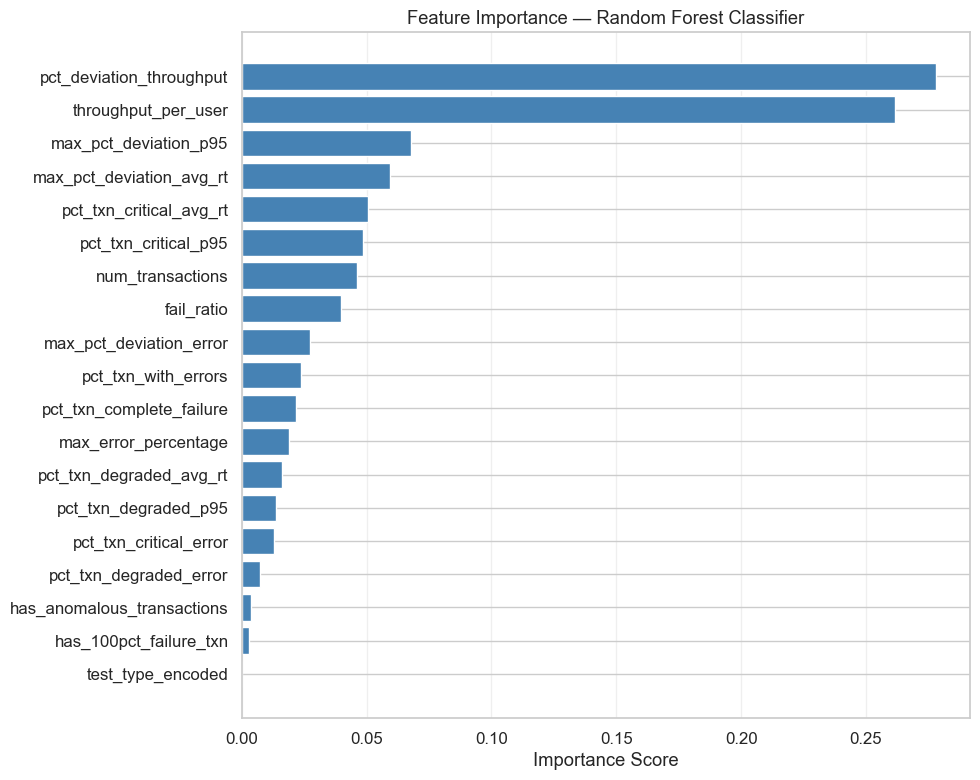


📊 Top 5 Most Important Features:
   1. pct_deviation_throughput       (0.278)
   2. throughput_per_user            (0.261)
   3. max_pct_deviation_p95          (0.068)
   4. max_pct_deviation_avg_rt       (0.059)
   5. pct_txn_critical_avg_rt        (0.051)


In [13]:
# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(MODEL_FEATURES)), importances[indices[::-1]], color='steelblue')
ax.set_yticks(range(len(MODEL_FEATURES)))
ax.set_yticklabels([MODEL_FEATURES[i] for i in indices[::-1]])
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest Classifier')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\n📊 Top 5 Most Important Features:')
for i in range(5):
    idx = indices[i]
    print(f'   {i+1}. {MODEL_FEATURES[idx]:30s} ({importances[idx]:.3f})')

## 6. Confusion Matrix (from Test Set)

Display the confusion matrix from model evaluation on 143 held-out test runs.

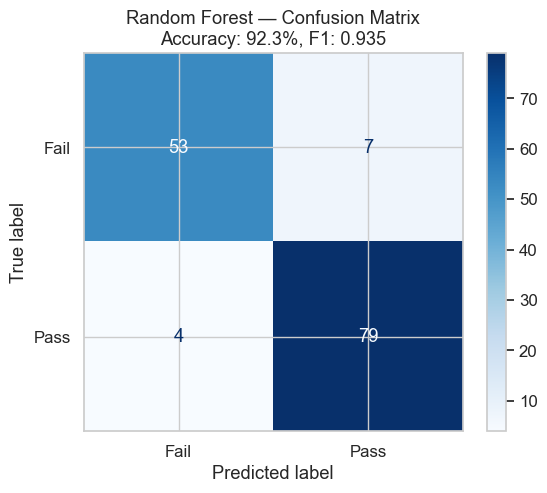


📊 Random Forest Performance on 143 Test Runs:
   True Negatives (TN):   53  (Correctly predicted FAIL)
   False Positives (FP):   7  (Incorrectly predicted PASS)
   False Negatives (FN):   4  (Incorrectly predicted FAIL)
   True Positives (TP):   79  (Correctly predicted PASS)


In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = metrics['best_model']
m = metrics[best_model]

# Reconstruct confusion matrix from stored values
cm = np.array([[m['TN'], m['FP']], 
               [m['FN'], m['TP']]])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'{best_model} — Confusion Matrix\n'
             f'Accuracy: {m["accuracy"]:.1%}, F1: {m["f1_score"]:.3f}')
plt.tight_layout()
plt.show()

print(f'\n📊 {best_model} Performance on 143 Test Runs:')
print(f'   True Negatives (TN):  {m["TN"]:3d}  (Correctly predicted FAIL)')
print(f'   False Positives (FP): {m["FP"]:3d}  (Incorrectly predicted PASS)')
print(f'   False Negatives (FN): {m["FN"]:3d}  (Incorrectly predicted FAIL)')
print(f'   True Positives (TP):  {m["TP"]:3d}  (Correctly predicted PASS)')

## Conclusion

✅ **Model successfully demonstrated:**
- Loaded pre-trained Random Forest classifier (93% accuracy)
- Made predictions on 3 representative test cases
- Displayed confidence scores and feature explanations
- Visualized feature importance

**Next Steps:**
- Run `python -m src.predict` for command-line predictions
- Launch Streamlit app: `streamlit run app.py`
- Try `evaluation.ipynb` to see full training pipeline